# MLA Week 4 Lab — Logistic Regression and Gradient Descent
**Machine Learning Applications (MLA), Hanoi University (HANU)** · Semester 1, AY 2026–2027

This lab turns the Week 4 lecture into working code. You will implement the
logistic model, its cross-entropy loss, and gradient descent **from first
principles** (no `scikit-learn` for the core maths), then apply them to a
synthetic Eedi-style task: predicting whether a student answers a question
correctly.

> **Data note.** The dataset here is generated inside the notebook, so the lab
> is self-contained and runs on Google Colab with no file upload. The *same
> modeling pattern* is intended to transfer to the real Eedi response CSVs
> (`train_data.csv`, ...) after adapting the data-loading and feature-
> construction cell; that step is not run in this lab.

## 1. Learning objectives

By the end of this lab you should be able to:

1. implement the sigmoid and the cross-entropy loss and read their values;
2. compute the logistic gradient `(1/N) Xᵀ(p − t)` and take one update by hand and in code;
3. train logistic regression with full-batch gradient descent from scratch;
4. compare batch, mini-batch, and stochastic gradient descent, and the effect of the learning rate;
5. cross-check your model against `scikit-learn`;
6. evaluate a classifier with accuracy, precision, recall, and a confusion matrix, and see why accuracy alone is misleading on imbalanced data;
7. state the responsible-use framing for the predicted probability.

## 2. Setup and imports

In [1]:
# Core scientific stack. numpy for the maths, matplotlib for plots.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # fixed seed: results are reproducible
np.set_printoptions(precision=4, suppress=True)

## 3. Part A — Sigmoid and cross-entropy on the four-point case

We start from the exact four points used in the lecture and the tutorial:

$$x = [-2,-1,1,2], \qquad t = [0,0,1,1].$$

With the starting weights $w_0 = 0$, $w_1 = 1$, the score is $z = w_0 + w_1 x$
and the probability is $p = \sigma(z)$. The per-attempt loss is cross-entropy
$L = -t\log p - (1-t)\log(1-p)$, and the cost $J$ is its average.

Implement `sigmoid` and `cross_entropy`, then confirm $J \approx 0.22$.

In [2]:
def sigmoid(z):
    # Equivalent to 1 / (1 + exp(-z)), without exponential overflow.
    z = np.asarray(z, dtype=float)
    return np.exp(-np.logaddexp(0.0, -z))

def cross_entropy(p, t):
    # Clip only at the boundaries to keep log(0) finite.
    p = np.clip(p, 1e-12, 1.0 - 1e-12)
    return float(-np.mean(t * np.log(p) + (1.0 - t) * np.log1p(-p)))

x = np.array([-2.0, -1.0, 1.0, 2.0])
t = np.array([0.0, 0.0, 1.0, 1.0])
X = np.column_stack([np.ones_like(x), x])
w = np.array([0.0, 1.0])
p = sigmoid(X @ w)
J = cross_entropy(p, t)
print("p =", p)
print("J =", round(J, 4))

p = [0.1192 0.2689 0.7311 0.8808]
J = 0.2201


**Expected:** `p ≈ [0.12, 0.27, 0.73, 0.88]` and `J ≈ 0.2201`. Notice the two
wrong points (`t = 0`) get low probabilities and the two correct points
(`t = 1`) get high ones, even before any training.

## 4. Part B — One gradient step by hand

The gradient of the average cross-entropy is

$$\nabla_w J = \frac{1}{N} X^\top (p - t).$$

Implement it, take one step with learning rate $\alpha = 0.5$, and confirm the
gradient is about $[0,\,-0.25]$ and that $w_1$ moves from $1$ to about $1.13$.

In [3]:
def gradient(X, p, t):
    return X.T @ (p - t) / len(t)

g = gradient(X, p, t)
alpha = 0.5
w_new = w - alpha * g
print("gradient =", g)
print("w after one step =", w_new)
print("cost after one step =", round(cross_entropy(sigmoid(X @ w_new), t), 4))

gradient = [-0.     -0.2537]
w after one step = [0.     1.1268]
cost after one step = 0.1903


**By hand:** the residuals are approximately
`[0.1192, 0.2689, -0.2689, -0.1192]`. Their average is zero, so the
intercept gradient is zero. The slope gradient is
`(-2*0.1192 - 0.2689 - 0.2689 - 2*0.1192)/4 ≈ -0.2537`,
giving `w_new ≈ [0, 1.1268]`. Increasing the slope sharpens the sigmoid
and lowers the loss on these four points.

## 5. Part C — A synthetic Eedi-style dataset

Each row is one attempt: a student meets a question and answers it correctly
(`1`) or not (`0`). We build three pre-attempt features and a binary target
whose true probability follows a logistic rule. This mimics the Eedi task; on
the real data you would load the CSVs instead.

In [4]:
# Synthetic (student, question) attempts. Features are known before the attempt.
N = 4000
ability    = rng.normal(0, 1, N)   # how strong the student is
difficulty = rng.normal(0, 1, N)   # how hard the question is
practice   = rng.normal(0, 1, N)   # recent practice signal

# True (hidden) rule the data follows, then sample a 0/1 outcome.
# The +1.3 intercept makes most answers correct (majority class), like Eedi,
# so the imbalance lesson in Part H is realistic.
z_true = 1.5 * ability - 1.5 * difficulty + 0.5 * practice + 1.3
p_true = 1.0 / (1.0 + np.exp(-z_true))
y = (rng.uniform(size=N) < p_true).astype(float)

# Design matrix: bias column, then the three features.
Xf = np.column_stack([np.ones(N), ability, difficulty, practice])

# Train / validation / test split (60 / 20 / 20).
idx = rng.permutation(N)
tr, va, te = idx[:2400], idx[2400:3200], idx[3200:]
Xtr, ytr = Xf[tr], y[tr]
Xva, yva = Xf[va], y[va]
Xte, yte = Xf[te], y[te]
print("class balance (fraction correct):", round(y.mean(), 3))
print("train / val / test sizes:", len(tr), len(va), len(te))

class balance (fraction correct): 0.676
train / val / test sizes: 2400 800 800


## 6. Part D — Logistic regression from scratch (full-batch gradient descent)

Now train on the synthetic data by repeating the update
$w \leftarrow w - \alpha\,\nabla_w J$ for a number of epochs, reusing your
`sigmoid`, `cross_entropy`, and `gradient` functions.

weights [bias, ability, difficulty, practice]: [ 1.2662  1.4603 -1.5789  0.4688]
train accuracy: 0.812
training cost, first / last epoch: 0.6632 0.4042


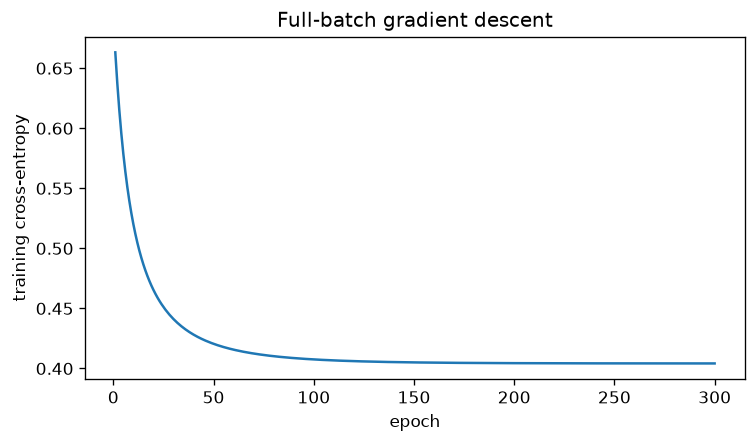

In [5]:
def train_full_batch(X, t, alpha=0.3, epochs=300):
    w = np.zeros(X.shape[1])
    history = []
    for _ in range(epochs):
        p = sigmoid(X @ w)
        w = w - alpha * gradient(X, p, t)
        # Record the full training cost after each update.
        history.append(cross_entropy(sigmoid(X @ w), t))
    return w, history

def accuracy(X, t, w, thr=0.5):
    return float(np.mean((sigmoid(X @ w) >= thr) == (t == 1)))

w_gd, hist = train_full_batch(Xtr, ytr, alpha=0.3, epochs=300)
print("weights [bias, ability, difficulty, practice]:", w_gd)
print("train accuracy:", round(accuracy(Xtr, ytr, w_gd), 3))
print("training cost, first / last epoch:", round(hist[0], 4), round(hist[-1], 4))
plt.figure(figsize=(6.4, 3.8))
plt.plot(np.arange(1, len(hist) + 1), hist)
plt.xlabel("epoch"); plt.ylabel("training cross-entropy")
plt.title("Full-batch gradient descent"); plt.tight_layout(); plt.show()

The learned weights should roughly recover the sign and relative size of the
true rule: positive on ability, negative on difficulty. The loss curve should
fall smoothly and flatten.

## 7. Part E — Batch vs mini-batch vs stochastic gradient descent

The only change is how many attempts each step uses. Here we compare full
batch (all data), mini-batch (32), and SGD (1). All three should drive the loss
down; SGD is the noisiest per step but the cheapest.

Batch (all): final loss = 0.4282; updates/epoch = 1
Mini-batch (32): final loss = 0.4049; updates/epoch = 75
SGD (1): final loss = 0.4171; updates/epoch = 2400


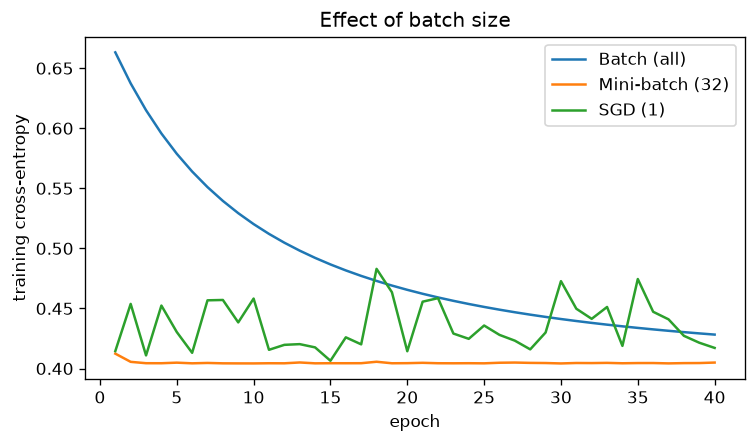

In [6]:
def train_minibatch(X, t, alpha=0.3, epochs=40, batch_size=32, seed=0):
    r = np.random.default_rng(seed)
    w = np.zeros(X.shape[1])
    n = len(t)
    epoch_loss = []
    for _ in range(epochs):
        order = r.permutation(n)
        for start in range(0, n, batch_size):
            b = order[start:start + batch_size]
            p = sigmoid(X[b] @ w)
            w = w - alpha * (X[b].T @ (p - t[b]) / len(b))
        epoch_loss.append(cross_entropy(sigmoid(X @ w), t))
    return w, epoch_loss

configs = [("Batch (all)", len(ytr)), ("Mini-batch (32)", 32), ("SGD (1)", 1)]
plt.figure(figsize=(6.4, 3.8))
for label, bs in configs:
    _, loss = train_minibatch(Xtr, ytr, alpha=0.3, epochs=40, batch_size=bs)
    plt.plot(np.arange(1, len(loss) + 1), loss, label=label)
    print(f"{label}: final loss = {loss[-1]:.4f}; updates/epoch = {int(np.ceil(len(ytr) / bs))}")
plt.xlabel("epoch"); plt.ylabel("training cross-entropy")
plt.legend(); plt.title("Effect of batch size"); plt.tight_layout(); plt.show()

## 8. Part F — Learning-rate sweep

Too small and training crawls; too big and it overshoots or diverges. Watch the
loss curves for a range of $\alpha$.

alpha = 0.01: first loss = 0.6921, final loss = 0.5981
alpha = 0.1: first loss = 0.6829, final loss = 0.4288
alpha = 1: first loss = 0.6018, final loss = 0.4042
alpha = 3: first loss = 0.4841, final loss = 0.4042
alpha = 30: first loss = 0.7357, final loss = 1.1231


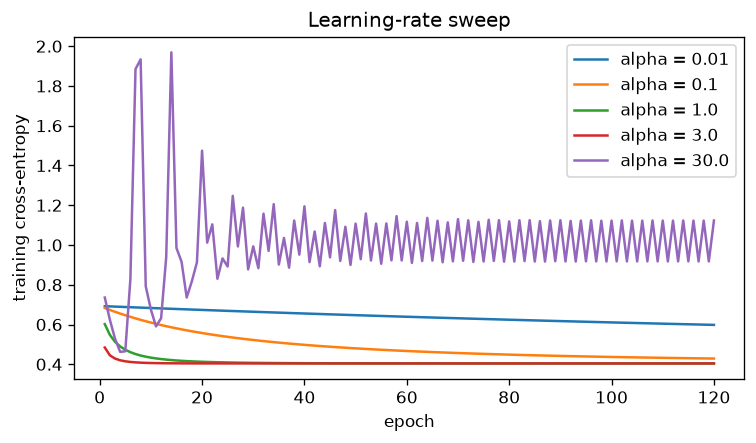

In [7]:
plt.figure(figsize=(6.4, 3.8))
for alpha in [0.01, 0.1, 1.0, 3.0, 30.0]:
    _, loss = train_full_batch(Xtr, ytr, alpha=alpha, epochs=120)
    plt.plot(np.arange(1, len(loss) + 1), loss, label=f"alpha = {alpha}")
    print(f"alpha = {alpha:g}: first loss = {loss[0]:.4f}, final loss = {loss[-1]:.4f}")
plt.xlabel("epoch"); plt.ylabel("training cross-entropy")
plt.legend(); plt.title("Learning-rate sweep")
plt.tight_layout(); plt.show()

The printed losses and curves show how learning rate affects convergence.
The original rates are retained; `alpha = 30` is added to illustrate an
excessively large step on this dataset. The vertical axis is not clipped,
so unstable behavior remains visible. A rate of `3` is not necessarily too
large: stability depends on the data and the curvature of the objective.

## 9. Part G — Cross-check with scikit-learn

A sanity check: `scikit-learn`'s `LogisticRegression` (with regularization
turned off) should reach a very similar accuracy to our from-scratch model.

In [8]:
from sklearn.linear_model import LogisticRegression

# C=np.inf disables regularization (current scikit-learn API).
# Our Xtr already has a bias column, so disable sklearn's own intercept.
clf = LogisticRegression(C=np.inf, fit_intercept=False, max_iter=1000, tol=1e-10)
clf.fit(Xtr, ytr)
print("sklearn weights   :", clf.coef_.ravel())
print("from-scratch       :", w_gd)
print("sklearn val acc    :", round(clf.score(Xva, yva), 3))
print("from-scratch val ac:", round(accuracy(Xva, yva, w_gd), 3))

sklearn weights   : [ 1.2828  1.4812 -1.6013  0.476 ]
from-scratch       : [ 1.2662  1.4603 -1.5789  0.4688]
sklearn val acc    : 0.816
from-scratch val ac: 0.815


## 10. Part H — Evaluation: accuracy is not enough

We evaluate on the held-out test set. Accuracy alone can be misleading, so we
also compute precision, recall, and the confusion matrix, and we compare
against a lazy baseline that always predicts "correct".

TP=496, FP=77, FN=58, TN=169
Confusion matrix (rows=true, columns=predicted; order=[0, 1]):
[[169  77]
 [ 58 496]]
Accuracy: 0.8313
Precision (correct class): 0.8656
Recall (correct class): 0.8953
F1 (correct class): 0.8802
Always-correct baseline accuracy: 0.6925
Wrong-answer recall: 0.6870 (baseline: 0.0000)


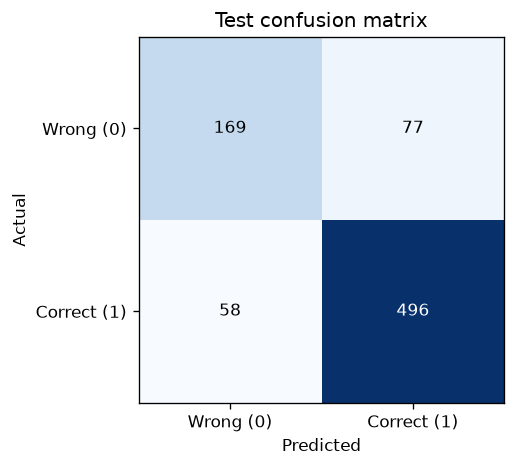

In [9]:
def confusion(t, pred):
    t, pred = np.asarray(t), np.asarray(pred)
    TP = int(np.sum((pred == 1) & (t == 1)))
    FP = int(np.sum((pred == 1) & (t == 0)))
    FN = int(np.sum((pred == 0) & (t == 1)))
    TN = int(np.sum((pred == 0) & (t == 0)))
    return TP, FP, FN, TN

p_test = sigmoid(Xte @ w_gd)
pred = (p_test >= 0.5).astype(float)
TP, FP, FN, TN = confusion(yte, pred)
test_accuracy = (TP + TN) / len(yte)
precision = TP / (TP + FP) if TP + FP else 0.0
recall = TP / (TP + FN) if TP + FN else 0.0
f1 = 2 * TP / (2 * TP + FP + FN) if 2 * TP + FP + FN else 0.0
baseline_accuracy = float(np.mean(yte == 1))
wrong_recall = TN / (TN + FP) if TN + FP else 0.0
cm = np.array([[TN, FP], [FN, TP]])
print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print("Confusion matrix (rows=true, columns=predicted; order=[0, 1]):")
print(cm)
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision (correct class): {precision:.4f}")
print(f"Recall (correct class): {recall:.4f}")
print(f"F1 (correct class): {f1:.4f}")
print(f"Always-correct baseline accuracy: {baseline_accuracy:.4f}")
print(f"Wrong-answer recall: {wrong_recall:.4f} (baseline: 0.0000)")

fig, ax = plt.subplots(figsize=(4.8, 4.0))
ax.imshow(cm, cmap="Blues")
for (row, col), count in np.ndenumerate(cm):
    ax.text(col, row, str(count), ha="center", va="center",
            color="white" if count > cm.max() / 2 else "black")
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=["Wrong (0)", "Correct (1)"],
       yticklabels=["Wrong (0)", "Correct (1)"],
       xlabel="Predicted", ylabel="Actual", title="Test confusion matrix")
plt.tight_layout(); plt.show()

The always-correct baseline has accuracy equal to the test-set fraction of
correct answers, but its recall for wrong answers is zero. Compare both its
accuracy and wrong-answer recall with the measured model values above;
positive-class recall alone does not measure how well a teacher-support tool
flags incorrect answers.

### Threshold sweep

The `0.5` threshold is a default, not a law. The plot tracks precision and
recall for the positive class (**answered correctly**), where we predict
"correct" when `p >= threshold`. Lowering the threshold labels more answers
correct, so correct-class **recall cannot decrease; precision often decreases**.

Reading it for the tool's actual job, **flagging likely-wrong answers**: the
flag is `p(correct) < threshold`, so *raising* the `p(correct)` cutoff sends
more borderline answers to the review queue. That catches more wrong answers
(higher recall on the wrong class) at the cost of more false alarms.

This test-set sweep is descriptive only. Choose any operational threshold on
validation data, using the costs of missed wrong answers and false alarms,
then evaluate the fixed choice on an untouched test set. Precision need not
be monotonic on a finite dataset.

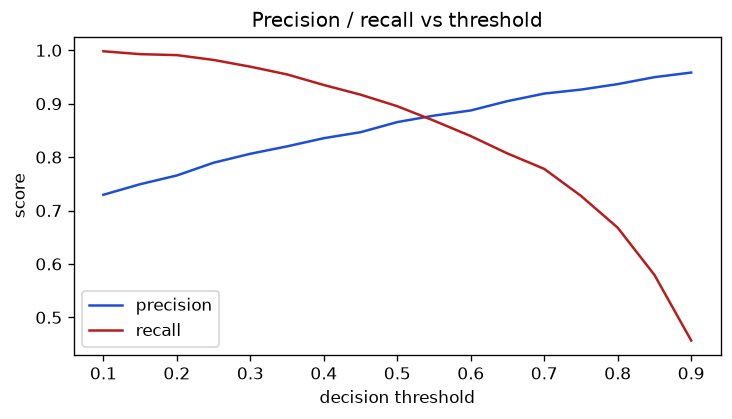

In [10]:
thresholds = np.linspace(0.1, 0.9, 17)
precisions, recalls = [], []
for thr in thresholds:
    pred = (p_test >= thr).astype(float)
    TP = np.sum((pred == 1) & (yte == 1))
    FP = np.sum((pred == 1) & (yte == 0))
    FN = np.sum((pred == 0) & (yte == 1))
    precisions.append(TP / (TP + FP + 1e-9))
    recalls.append(TP / (TP + FN + 1e-9))

plt.figure(figsize=(6.2, 3.6))
plt.plot(thresholds, precisions, label="precision", color="#1D4ED8")
plt.plot(thresholds, recalls, label="recall", color="#B91C1C")
plt.xlabel("decision threshold"); plt.ylabel("score")
plt.legend(); plt.title("Precision / recall vs threshold")
plt.tight_layout(); plt.show()

## 11. Part I — Responsible-use reflection

Write two or three sentences answering the following (edit the string below):

1. The model outputs a *probability* that an answer is correct. Why is a
   near-0.5 probability the most useful output for a teacher-support tool?
2. Give one concrete harm that could follow if a wrong-answer flag were used to
   auto-grade a student with no human review.

In [11]:
reflection = '''
A probability near 0.5 indicates that the model is uncertain, making the
attempt a useful candidate for teacher review rather than a confident
automatic decision. Its usefulness depends on calibration and the teacher's
review goals; the score is an estimate for an attempt, not a judgment of the
student's ability or worth. If a wrong-answer flag automatically determined
a grade, a false flag could penalize a correct response and unfairly lower
the student's mark, so a teacher should check the actual work.
'''
print(reflection)


A probability near 0.5 indicates that the model is uncertain, making the
attempt a useful candidate for teacher review rather than a confident
automatic decision. Its usefulness depends on calibration and the teacher's
review goals; the score is an estimate for an attempt, not a judgment of the
student's ability or worth. If a wrong-answer flag automatically determined
a grade, a false flag could penalize a correct response and unfairly lower
the student's mark, so a teacher should check the actual work.



## 12. Summary

- The logistic model wraps a sigmoid around a linear score to output a probability.
- Cross-entropy is the matching loss; its gradient is the familiar `Xᵀ(p − t) / N`.
- Gradient descent trains it; mini-batch and SGD trade exact steps for many cheap ones.
- The learning rate controls convergence; too big overshoots.
- Evaluate with precision, recall, and the confusion matrix, not accuracy alone, and treat the probability as decision support with a teacher in the loop.

**Submit** your completed notebook (all cells run, outputs visible) as part of
the lab portfolio.

## Execution notes and checks

This completed solution was generated with AI assistance from the supplied
starter. All code cells were executed sequentially with seed 42; outputs and
plots are saved. Environment: Python 3.14.7, NumPy
2.5.2, Matplotlib 3.11.1, scikit-learn 1.9.0.

Checks passed: the four-point reference values, extreme sigmoid inputs,
finite-difference gradient agreement, decreasing full-batch loss, coefficient
agreement with scikit-learn after 2,000 verification epochs (maximum absolute
difference below 0.0001), training loss within 0.0001 of the library optimum
after the prescribed 300 epochs, and
test confusion matrix/precision/recall/F1 agreement with scikit-learn.

In Part E, an epoch gives each example one visit, but means 1 update for
full batch, 75 for mini-batch, and 2,400 for SGD. The figure compares equal
epochs, not equal numbers of updates or equal wall-clock time; the fixed
learning rate can leave SGD fluctuating near the solution.

The library comparison uses the documented unregularized configuration
[`C=np.inf`, `fit_intercept=False`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).
